In [6]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"arnobreduan","key":"2ede18c97836f416dcd171b701c094c2"}'}

In [7]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [8]:
!kaggle competitions download -c aptos2019-blindness-detection

100% 9.51G/9.51G [01:37<00:00, 105MB/s]



In [9]:
!unzip aptos2019-blindness-detection.zip -d aptos_data

Streaming output truncated to the last 5000 lines.
  inflating: aptos_data/test_images/512beaada8f0.png  
  inflating: aptos_data/test_images/51323e9d2070.png  
  inflating: aptos_data/test_images/515675001b9e.png  
  inflating: aptos_data/test_images/515877da2def.png  
  inflating: aptos_data/test_images/5168ddccea88.png  
  inflating: aptos_data/test_images/5172c056a687.png  
  inflating: aptos_data/test_images/5177461f5339.png  
  inflating: aptos_data/test_images/51910bcb980d.png  
  inflating: aptos_data/test_images/51a3e9b6a1c0.png  
  inflating: aptos_data/test_images/51bbd82feec8.png  
  inflating: aptos_data/test_images/51de5fb8eccd.png  
  inflating: aptos_data/test_images/51e88694c81f.png  
  inflating: aptos_data/test_images/51f0bf8f1544.png  
  inflating: aptos_data/test_images/51f57fb32840.png  
  inflating: aptos_data/test_images/51fa42dc1415.png  
  inflating: aptos_data/test_images/5276ab33b7b0.png  
  inflating: aptos_data/test_images/52a353760f72.png  
  inflating: a

In [10]:
import os
import copy
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from IPython.display import display

try:
    from torchsummary import summary
except:
    !pip -q install torchsummary
    from torchsummary import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [16]:
# =========================================================
# Hyperparameters and Reproducibility
# =========================================================
batch_size = 32
learning_rate = 0.001
minimum_learning_rate = 1e-5
epochs = 3
num_classes = 5
image_size = 128
random_seed = 42

torch.manual_seed(random_seed)
np.random.seed(random_seed)
random.seed(random_seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)

# =========================================================
# Custom Dataset
# =========================================================
class APTOSDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.data_df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.data_df)

    def __getitem__(self, idx):
        img_id = self.data_df.iloc[idx]["id_code"]
        label = int(self.data_df.iloc[idx]["diagnosis"])

        img_path = os.path.join(self.root_dir, img_id + ".png")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

print("Hyperparameters:")
print(f"Batch Size           : {batch_size}")
print(f"Learning Rate        : {learning_rate}")
print(f"Minimum Learning Rate: {minimum_learning_rate}")
print(f"Epochs               : {epochs}")
print(f"Number of Classes    : {num_classes}")
print(f"Image Size           : {image_size}x{image_size}")

Hyperparameters:
Batch Size           : 32
Learning Rate        : 0.001
Minimum Learning Rate: 1e-05
Epochs               : 3
Number of Classes    : 5
Image Size           : 128x128


In [17]:
# =========================================================
# Data Loading, Preprocessing, Splitting, and DataLoaders
# =========================================================

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

csv_path = "aptos_data/train.csv"
img_dir = "aptos_data/train_images"

train_dataset_full = APTOSDataset(csv_path, img_dir, transform=train_transform)
eval_dataset_full  = APTOSDataset(csv_path, img_dir, transform=eval_transform)

dataset_df = pd.read_csv(csv_path)
print("Dataset shape:", dataset_df.shape)
print("\nClass distribution:")
display(dataset_df["diagnosis"].value_counts().sort_index().to_frame(name="count"))

# Fixed split indices so train/val/test stay consistent
dataset_size = len(dataset_df)
indices = np.arange(dataset_size)
np.random.shuffle(indices)

train_end = int(0.70 * dataset_size)
val_end   = int(0.85 * dataset_size)

train_indices = indices[:train_end]
val_indices   = indices[train_end:val_end]
test_indices  = indices[val_end:]

train_data = Subset(train_dataset_full, train_indices)
val_data   = Subset(eval_dataset_full, val_indices)
test_data  = Subset(eval_dataset_full, test_indices)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"\nTotal samples      : {dataset_size}")
print(f"Training samples   : {len(train_data)}")
print(f"Validation samples : {len(val_data)}")
print(f"Test samples       : {len(test_data)}")

Dataset shape: (3662, 2)

Class distribution:


,count
diagnosis,
0,1805
1,370
2,999
3,193
4,295



Total samples      : 3662
Training samples   : 2563
Validation samples : 549
Test samples       : 550


In [19]:
# =========================================================
# CNN Architecture
# =========================================================

class CNNWithoutBNDropout(nn.Module):
    def __init__(self, num_classes=5):
        super(CNNWithoutBNDropout, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class CNNWithBNDropout(nn.Module):
    def __init__(self, num_classes=5):
        super(CNNWithBNDropout, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


baseline_model = CNNWithoutBNDropout(num_classes=num_classes).to(device)
regularized_model = CNNWithBNDropout(num_classes=num_classes).to(device)

print("Baseline Model Summary (Without BatchNorm and Dropout)")
summary(baseline_model, input_size=(3, image_size, image_size))

print("\n" + "=" * 70 + "\n")

print("Regularized Model Summary (With BatchNorm and Dropout)")
summary(regularized_model, input_size=(3, image_size, image_size))

Baseline Model Summary (Without BatchNorm and Dropout)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
              ReLU-2         [-1, 32, 128, 128]               0
         MaxPool2d-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
              ReLU-5           [-1, 64, 64, 64]               0
         MaxPool2d-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
              ReLU-8          [-1, 128, 32, 32]               0
         MaxPool2d-9          [-1, 128, 16, 16]               0
           Conv2d-10          [-1, 128, 16, 16]         147,584
             ReLU-11          [-1, 128, 16, 16]               0
        MaxPool2d-12            [-1, 128, 8, 8]               0
          Flatten-13                 [-1, 8192] 

In [20]:
# =========================================================
# Training and Evaluation Functions
# =========================================================

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def train_model(model, train_loader, val_loader, device, epochs, learning_rate, minimum_learning_rate):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)

        scheduler.step()

        if optimizer.param_groups[0]["lr"] < minimum_learning_rate:
            optimizer.param_groups[0]["lr"] = minimum_learning_rate

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Val   Accuracy: {val_acc:.4f}")
        print(f"Current Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
        print("-" * 60)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)
    return model, history, best_val_acc


def evaluate_model(model, loader, device):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0
    )

    return all_labels, all_preds, accuracy, precision, recall, f1

In [21]:
# =========================================================
# Train Both Models
# =========================================================

print("Training Baseline Model (Without BatchNorm and Dropout)\n")
baseline_model, baseline_history, baseline_best_val_acc = train_model(
    baseline_model,
    train_loader,
    val_loader,
    device,
    epochs,
    learning_rate,
    minimum_learning_rate
)

print("\n" + "=" * 80 + "\n")

print("Training Regularized Model (With BatchNorm and Dropout)\n")
regularized_model, regularized_history, regularized_best_val_acc = train_model(
    regularized_model,
    train_loader,
    val_loader,
    device,
    epochs,
    learning_rate,
    minimum_learning_rate
)

print("\nTraining completed.")
print(f"Best Validation Accuracy of Baseline Model   : {baseline_best_val_acc:.4f}")
print(f"Best Validation Accuracy of Regularized Model: {regularized_best_val_acc:.4f}")

Training Baseline Model (Without BatchNorm and Dropout)



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/3]
Train Loss: 0.9975 | Train Accuracy: 0.6290
Val   Loss: 0.8758 | Val   Accuracy: 0.6794
Current Learning Rate: 0.001000
------------------------------------------------------------
Epoch [2/3]
Train Loss: 0.8764 | Train Accuracy: 0.6925
Val   Loss: 0.8849 | Val   Accuracy: 0.6831
Current Learning Rate: 0.001000
------------------------------------------------------------
Epoch [3/3]
Train Loss: 0.8240 | Train Accuracy: 0.7027
Val   Loss: 0.7685 | Val   Accuracy: 0.6922
Current Learning Rate: 0.000500
------------------------------------------------------------


Training Regularized Model (With BatchNorm and Dropout)

Epoch [1/3]
Train Loss: 1.3995 | Train Accuracy: 0.6028
Val   Loss: 0.8350 | Val   Accuracy: 0.6995
Current Learning Rate: 0.001000
------------------------------------------------------------
Epoch [2/3]
Train Loss: 0.9099 | Train Accuracy: 0.6797
Val   Loss: 0.7679 | Val   Accuracy: 0.7213
Current Learning Rate: 0.001000
-------------------------------------

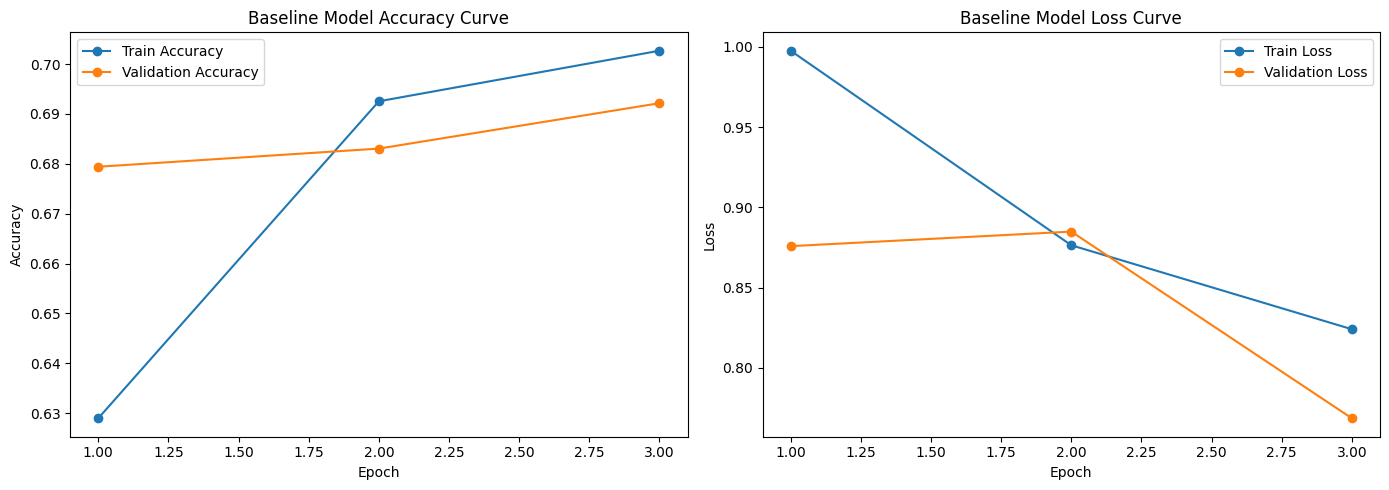

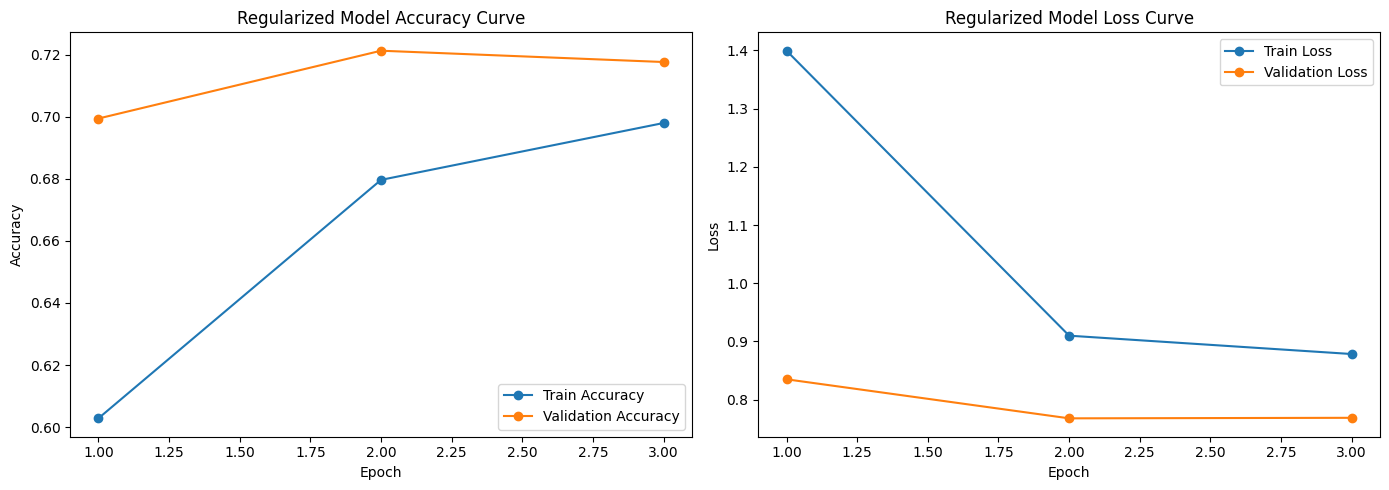

In [22]:
# =========================================================
# Training and Validation Curves
# =========================================================

epochs_range = range(1, epochs + 1)

# Baseline model curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, baseline_history["train_acc"], marker='o', label="Train Accuracy")
plt.plot(epochs_range, baseline_history["val_acc"], marker='o', label="Validation Accuracy")
plt.title("Baseline Model Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, baseline_history["train_loss"], marker='o', label="Train Loss")
plt.plot(epochs_range, baseline_history["val_loss"], marker='o', label="Validation Loss")
plt.title("Baseline Model Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


# Regularized model curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, regularized_history["train_acc"], marker='o', label="Train Accuracy")
plt.plot(epochs_range, regularized_history["val_acc"], marker='o', label="Validation Accuracy")
plt.title("Regularized Model Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, regularized_history["train_loss"], marker='o', label="Train Loss")
plt.plot(epochs_range, regularized_history["val_loss"], marker='o', label="Validation Loss")
plt.title("Regularized Model Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

Baseline Model Test Results
Accuracy : 0.7091
Precision: 0.6793
Recall   : 0.7091
F1-score : 0.6815

Classification Report (Baseline):
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       282
           1       0.37      0.61      0.46        59
           2       0.55      0.71      0.62       136
           3       0.40      0.06      0.11        31
           4       0.00      0.00      0.00        42

    accuracy                           0.71       550
   macro avg       0.45      0.46      0.42       550
weighted avg       0.68      0.71      0.68       550





/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Regularized Model Test Results
Accuracy : 0.7091
Precision: 0.5790
Recall   : 0.7091
F1-score : 0.6284

Classification Report (Regularized):
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       282
           1       0.00      0.00      0.00        59
           2       0.49      0.90      0.64       136
           3       0.00      0.00      0.00        31
           4       0.00      0.00      0.00        42

    accuracy                           0.71       550
   macro avg       0.28      0.37      0.31       550
weighted avg       0.58      0.71      0.63       550



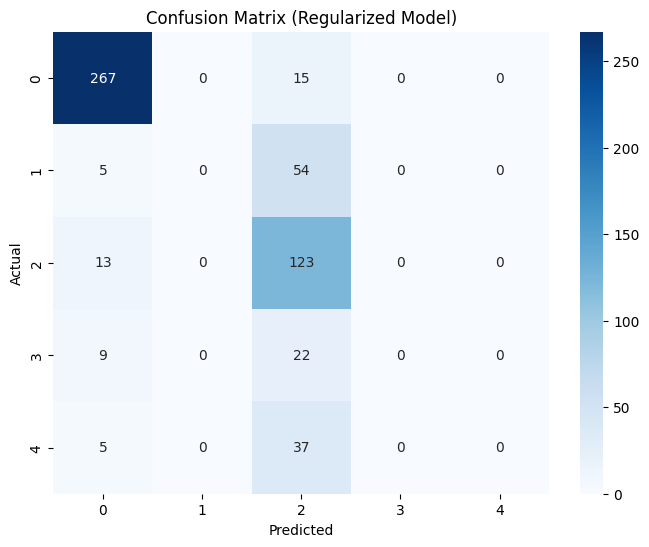


Per-class F1 scores:
Class 0: 0.9191
Class 1: 0.0000
Class 2: 0.6357
Class 3: 0.0000
Class 4: 0.0000

Best Class : 0
Worst Class: 1


In [23]:
# =========================================================
# Test Set Evaluation
# =========================================================

# Baseline model
baseline_labels, baseline_preds, baseline_acc, baseline_precision, baseline_recall, baseline_f1 = evaluate_model(
    baseline_model, test_loader, device
)

print("Baseline Model Test Results")
print(f"Accuracy : {baseline_acc:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1-score : {baseline_f1:.4f}")
print("\nClassification Report (Baseline):")
print(classification_report(baseline_labels, baseline_preds, zero_division=0))

print("\n" + "="*80 + "\n")

# Regularized model
regularized_labels, regularized_preds, regularized_acc, regularized_precision, regularized_recall, regularized_f1 = evaluate_model(
    regularized_model, test_loader, device
)

print("Regularized Model Test Results")
print(f"Accuracy : {regularized_acc:.4f}")
print(f"Precision: {regularized_precision:.4f}")
print(f"Recall   : {regularized_recall:.4f}")
print(f"F1-score : {regularized_f1:.4f}")
print("\nClassification Report (Regularized):")
print(classification_report(regularized_labels, regularized_preds, zero_division=0))


# Confusion matrix (Regularized)
cm = confusion_matrix(regularized_labels, regularized_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Regularized Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Best / Worst class analysis
report_dict = classification_report(
    regularized_labels,
    regularized_preds,
    output_dict=True,
    zero_division=0
)

class_f1_scores = {}
for k, v in report_dict.items():
    if k.isdigit():
        class_f1_scores[int(k)] = v["f1-score"]

best_class = max(class_f1_scores, key=class_f1_scores.get)
worst_class = min(class_f1_scores, key=class_f1_scores.get)

print("\nPer-class F1 scores:")
for cls, score in class_f1_scores.items():
    print(f"Class {cls}: {score:.4f}")

print(f"\nBest Class : {best_class}")
print(f"Worst Class: {worst_class}")

In [24]:
# =========================================================
# Save Best Model
# =========================================================

if regularized_acc >= baseline_acc:
    best_model = regularized_model
    model_name = "cnn_with_bn_dropout_best.pth"
    model_type = "Regularized Model"
else:
    best_model = baseline_model
    model_name = "cnn_without_bn_dropout_best.pth"
    model_type = "Baseline Model"

torch.save(best_model.state_dict(), model_name)

print(f"Best model: {model_type}")
print(f"Saved as: {model_name}")

Best model: Regularized Model
Saved as: cnn_with_bn_dropout_best.pth
